<a href="https://colab.research.google.com/github/KrisDA-1/ML_UrbanCrime/blob/main/FinalDissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##PROJECT:
          "A Comparative Analysis of Supervised Machine Learning technologies for Crime Risk Prediction Using Large-Scale Urban Data: A London Case Study"
#####AUTHOR:  Krisnha Rueda


In [21]:
# =============================================================================
# 1. ENVIRONMENT SETUP
# =============================================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report,
                             precision_recall_curve, ConfusionMatrixDisplay,
                             roc_curve, auc, precision_score, recall_score)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
!pip install shap lime -q
import shap
from lime.lime_tabular import LimeTabularExplainer

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

PROJECT_CONFIG = {
    'target_audience': 'University students & staff',
    'output_dir': '/content/drive/MyDrive/Dissertation/Output/',
    'random_state': 42
}
os.makedirs(PROJECT_CONFIG['output_dir'], exist_ok=True)
SEED = PROJECT_CONFIG['random_state']
OUT = PROJECT_CONFIG['output_dir']

In [3]:
# =============================================================================
# 2. LOADING DATA
# =============================================================================

DATA_PATH = Path("/content/drive/MyDrive/Dissertation/")

print("Loading datasets...")
try:
    knife_df = pd.read_csv(DATA_PATH / "M1045_KnifeCrimeData.csv")
    other_df = pd.read_csv(DATA_PATH / "M1045_OtherCrimeData.csv")
    tno_df   = pd.read_csv(DATA_PATH / "M1045_TNOCrimeData.csv", usecols=range(12))

    print(f"  Knife: {knife_df.shape}  |  Other: {other_df.shape}  |  TNO: {tno_df.shape}")

except FileNotFoundError as e:
    raise FileNotFoundError(f"❌ Missing file: {e}")

Loading datasets...
  Knife: (59431, 12)  |  Other: (415533, 12)  |  TNO: (859241, 12)


In [4]:
# =============================================================================
# 3. STANDARDISE COLUMN NAMES
# =============================================================================
COLUMN_MAP_KNIFE_OTHER = {
    'Month_Year': 'month_year', 'Area Type': 'area_type', 'Borough_SNT': 'borough',
    'Area Name': 'area_name', 'Area Code': 'area_code', 'Crime Type': 'crime_type',
    'Crime Subtype': 'crime_subtype', 'Measure': 'measure',
    'Financial Year': 'financial_year', 'FY_FYIndex': 'fy_index',
    'Count': 'count', 'Refresh Date': 'refresh_date'
}
COLUMN_MAP_TNO = {
    'Month_Year': 'month_year', 'Area Type': 'area_type', 'Borough_SNT': 'borough',
    'Area name': 'area_name', 'Area code': 'area_code', 'Offence Group': 'crime_type',
    'Offence Subgroup': 'crime_subtype', 'Measure': 'measure',
    'Financial Year': 'financial_year', 'FY_FYIndex': 'fy_index',
    'Count': 'count', 'Refresh Date': 'refresh_date'
}
knife_df = knife_df.rename(columns=COLUMN_MAP_KNIFE_OTHER)
other_df = other_df.rename(columns=COLUMN_MAP_KNIFE_OTHER)
tno_df   = tno_df.rename(columns=COLUMN_MAP_TNO)
print("Column names standardised.")

Column names standardised.


In [5]:
# =============================================================================
# 4. FILTER TO BOROUGH-LEVEL OFFENCES ONLY
# =============================================================================
knife_df = knife_df[(knife_df['area_type'] == 'Borough') & (knife_df['measure'] == 'Offences')].copy()
other_df = other_df[(other_df['area_type'] == 'Borough') & (other_df['measure'] == 'Offences')].copy()
tno_df   = tno_df[(tno_df['area_type'] == 'Borough') & (tno_df['measure'] == 'Offences')].copy()

EXCLUDE_BOROUGHS = {'Aviation Security', 'N/K', 'Unknown'}
for df in [knife_df, other_df, tno_df]:
    df.drop(df[df['borough'].isin(EXCLUDE_BOROUGHS)].index, inplace=True)
print(f"After filtering -> Knife: {len(knife_df)}  |  Other: {len(other_df)}  |  TNO: {len(tno_df)}")


After filtering -> Knife: 6954  |  Other: 24369  |  TNO: 42551


In [6]:
# =============================================================================
# 5. PARSE DATES & EXTRACT TEMPORAL FEATURES
# =============================================================================
for df in [knife_df, other_df, tno_df]:
    df['date'] = pd.to_datetime(df['month_year'], format='%d/%m/%Y')
    df['year']  = df['date'].dt.year
    df['month'] = df['date'].dt.month
print(f"Date range: {knife_df['date'].min().date()} to {knife_df['date'].max().date()}")

Date range: 2022-03-01 to 2026-02-01


In [7]:
# =============================================================================
# 6. ASSIGN CRIME GROUPS AND HIERARCHICAL RISK CATEGORIES
# =============================================================================
knife_df['crime_group'] = 'Knife Crime'
knife_df['risk_category'] = 'KNIFE_CRIME'

MOBILE_THEFT_SUBTYPES = {'ROBBERY MOBILE PHONE', 'THEFT PERSON - MOBILE PHONE'}
def map_other_crime(row):
    ct = str(row['crime_type']).upper()
    cs = str(row['crime_subtype']).upper()
    if cs in MOBILE_THEFT_SUBTYPES:
        return 'Theft & Robbery Mobile Phone'
    if any(kw in ct for kw in ['GUN CRIME', 'LETHAL BARREL', 'FIREARM']):
        return 'Gun Crime'
    if 'DOMESTIC' in ct:
        return 'Domestic Abuse'
    if 'HATE' in ct:
        return 'Hate Crime'
    return 'Miscellaneous'
other_df['crime_group'] = other_df.apply(map_other_crime, axis=1)

def map_tno_crime(offence_group):
    og = str(offence_group).upper()
    if 'SEXUAL' in og: return 'Sexual Offences'
    if 'THEFT' in og: return 'Theft'
    if any(kw in og for kw in ['VIOLENCE AGAINST', 'POSSESSION OF WEAPONS', 'ROBBERY']):
        return 'Violent Offences'
    if any(kw in og for kw in ['ARSON', 'CRIMINAL DAMAGE', 'BURGLARY', 'VEHICLE OFFENCES', 'PUBLIC ORDER']):
        return 'Property & Public Order'
    if any(kw in og for kw in ['DRUG', 'FRAUD']):
        return 'Drugs & Fraud'
    return 'Miscellaneous'
tno_df['crime_group'] = tno_df['crime_type'].apply(map_tno_crime)

RISK_HIERARCHY = {
    'Sexual Offences': 'SEXUAL_OFFENCES', 'Knife Crime': 'KNIFE_CRIME',
    'Gun Crime': 'WEAPON_CRIME', 'Theft': 'THEFT_ROBBERY',
    'Theft & Robbery Mobile Phone': 'THEFT_ROBBERY',
    'Hate Crime': 'OTHER_VIOLENT_CRIME', 'Violent Offences': 'OTHER_VIOLENT_CRIME',
    'Property & Public Order': 'OTHER', 'Drugs & Fraud': 'DRUGS_FRAUD',
    'Domestic Abuse': 'OTHER', 'Miscellaneous': 'OTHER'
}
for df in [knife_df, other_df, tno_df]:
    df['risk_category'] = df['crime_group'].map(RISK_HIERARCHY)

print("\nCrime group distribution:")
combined_groups = pd.concat([knife_df[['crime_group','risk_category']],
                             other_df[['crime_group','risk_category']],
                             tno_df[['crime_group','risk_category']]])
print(combined_groups.groupby(['risk_category','crime_group']).size()
      .reset_index(name='n_rows').sort_values('n_rows',ascending=False).to_string(index=False))


Crime group distribution:
      risk_category                  crime_group  n_rows
              OTHER      Property & Public Order   18178
OTHER_VIOLENT_CRIME                   Hate Crime   12155
OTHER_VIOLENT_CRIME             Violent Offences   10154
        KNIFE_CRIME                  Knife Crime    6954
      THEFT_ROBBERY                        Theft    6242
              OTHER                Miscellaneous    4793
        DRUGS_FRAUD                Drugs & Fraud    3292
              OTHER               Domestic Abuse    3242
      THEFT_ROBBERY Theft & Robbery Mobile Phone    3204
    SEXUAL_OFFENCES              Sexual Offences    3123
       WEAPON_CRIME                    Gun Crime    2537


In [8]:
# =============================================================================
# 7. COMBINE DATASETS & AGGREGATE TO BOROUGH-MONTH LEVEL
# =============================================================================
KEEP_COLS = ['borough', 'year', 'month', 'date', 'crime_group', 'risk_category', 'count']
df_all = pd.concat([knife_df[KEEP_COLS], other_df[KEEP_COLS], tno_df[KEEP_COLS]], ignore_index=True)
print(f"\nCombined dataset: {df_all.shape[0]:,} rows across "
      f"{df_all['borough'].nunique()} boroughs, {df_all['date'].nunique()} months")

RISK_PRIORITY = {
    'KNIFE_CRIME': 3.5, 'SEXUAL_OFFENCES': 5.0, 'WEAPON_CRIME': 4.0,
    'OTHER_VIOLENT_CRIME': 2.5, 'THEFT_ROBBERY': 4.5, 'DRUGS_FRAUD': 0.8, 'OTHER': 0.5
}
df_all['risk_score'] = df_all['risk_category'].map(RISK_PRIORITY).fillna(0.5)

df_agg = (df_all.groupby(['borough', 'year', 'month', 'date'])
    .agg(total_crime=('count','sum'), n_records=('count','count'),
         mean_risk=('risk_score','mean'), max_risk=('risk_score','max'),
         top_risk_cat=('risk_category', lambda x: x.value_counts().index[0]))
    .reset_index().sort_values(['borough','date']).reset_index(drop=True))
print(f"Aggregated dataset: {df_agg.shape[0]:,} borough-month observations")


Combined dataset: 73,874 rows across 33 boroughs, 48 months
Aggregated dataset: 1,584 borough-month observations


In [9]:
# =============================================================================
# 8. EDA: COMPREHENSIVE EXPLORATORY DATA ANALYSIS
# =============================================================================
print("\n" + "=" * 70)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 70)

# EDA 1: Dataset Info
print("\n--- EDA 1: Dataset Info ---")
print(f"Knife: {knife_df.shape}, Other: {other_df.shape}, TNO: {tno_df.shape}")
print(f"Combined: {df_all.shape}, Aggregated: {df_agg.shape}")


EXPLORATORY DATA ANALYSIS

--- EDA 1: Dataset Info ---
Knife: (6954, 17), Other: (24369, 17), TNO: (42551, 17)
Combined: (73874, 8), Aggregated: (1584, 9)



--- EDA 2: Missing Values ---
borough          0
year             0
month            0
date             0
crime_group      0
risk_category    0
count            0
risk_score       0


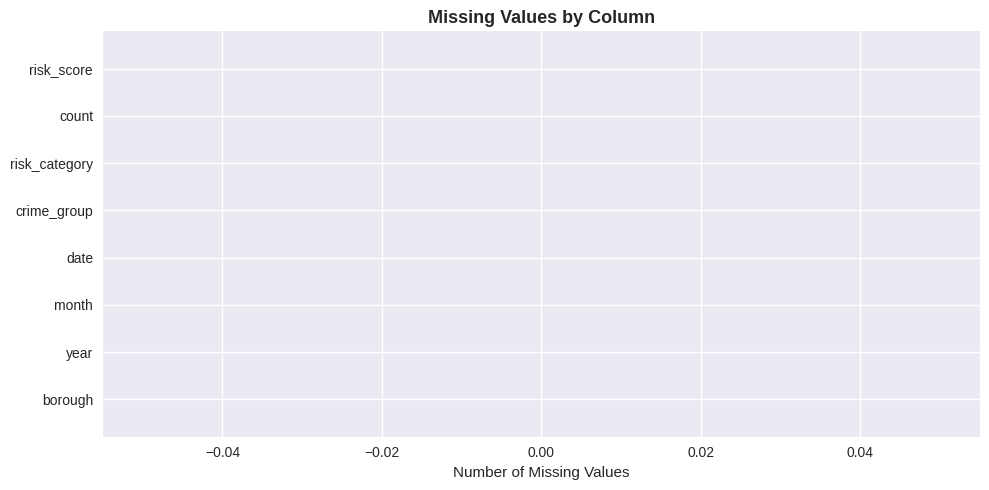

In [12]:
# EDA 2: Missing Values
print("\n--- EDA 2: Missing Values ---")
missing_all = df_all.isnull().sum()
print(missing_all.to_string())
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#DD8452' if v > 0 else '#55A868' for v in missing_all.values]
ax.barh(missing_all.index, missing_all.values, color=colors)
ax.set_xlabel('Number of Missing Values')
ax.set_title('Missing Values by Column', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(OUT + 'eda_missing_values.png', dpi=300); plt.show()

In [13]:
# EDA 3: Descriptive Statistics
print("\n--- EDA 3: Descriptive Statistics ---")
print(df_agg[['total_crime','n_records','mean_risk','max_risk']].describe().round(2).to_string())


--- EDA 3: Descriptive Statistics ---
       total_crime  n_records  mean_risk  max_risk
count      1584.00    1584.00    1584.00   1584.00
mean       5303.52      46.64       2.22      4.99
std        2613.78       4.16       0.07      0.06
min        1604.00      19.00       2.00      4.50
25%        3862.25      45.00       2.18      5.00
50%        5131.00      47.00       2.22      5.00
75%        6152.50      49.00       2.25      5.00
max       23134.00      67.00       2.76      5.00


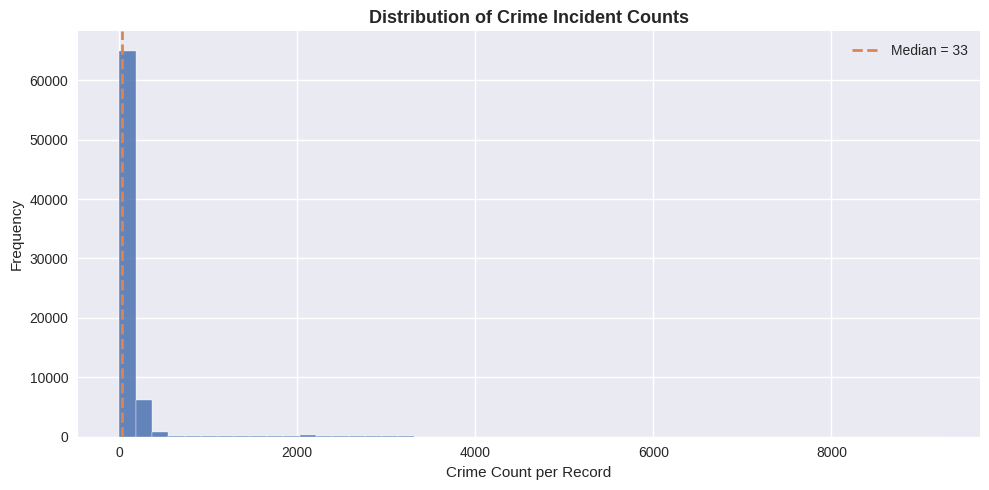

In [14]:
# EDA 4: Crime Count Distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_all['count'], bins=50, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.set_xlabel('Crime Count per Record'); ax.set_ylabel('Frequency')
ax.set_title('Distribution of Crime Incident Counts', fontsize=13, fontweight='bold')
ax.axvline(df_all['count'].median(), color='#DD8452', linestyle='--', linewidth=2,
           label=f"Median = {df_all['count'].median():.0f}")
ax.legend(); fig.tight_layout()
fig.savefig(OUT + 'eda_crime_count_distribution.png', dpi=300); plt.show()

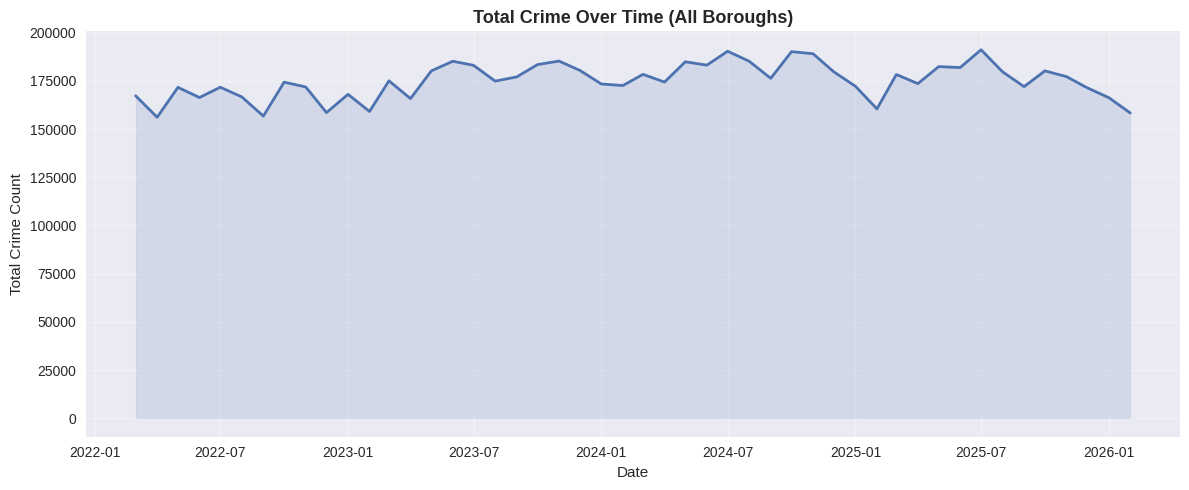

In [15]:
# EDA 5: Time vs Crime
monthly_total = df_all.groupby('date')['count'].sum().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_total['date'], monthly_total['count'], color='#4C72B0', linewidth=2)
ax.fill_between(monthly_total['date'], monthly_total['count'], alpha=0.15, color='#4C72B0')
ax.set_xlabel('Date'); ax.set_ylabel('Total Crime Count')
ax.set_title('Total Crime Over Time (All Boroughs)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3); fig.tight_layout()
fig.savefig(OUT + 'eda_time_vs_crime.png', dpi=300); plt.show()

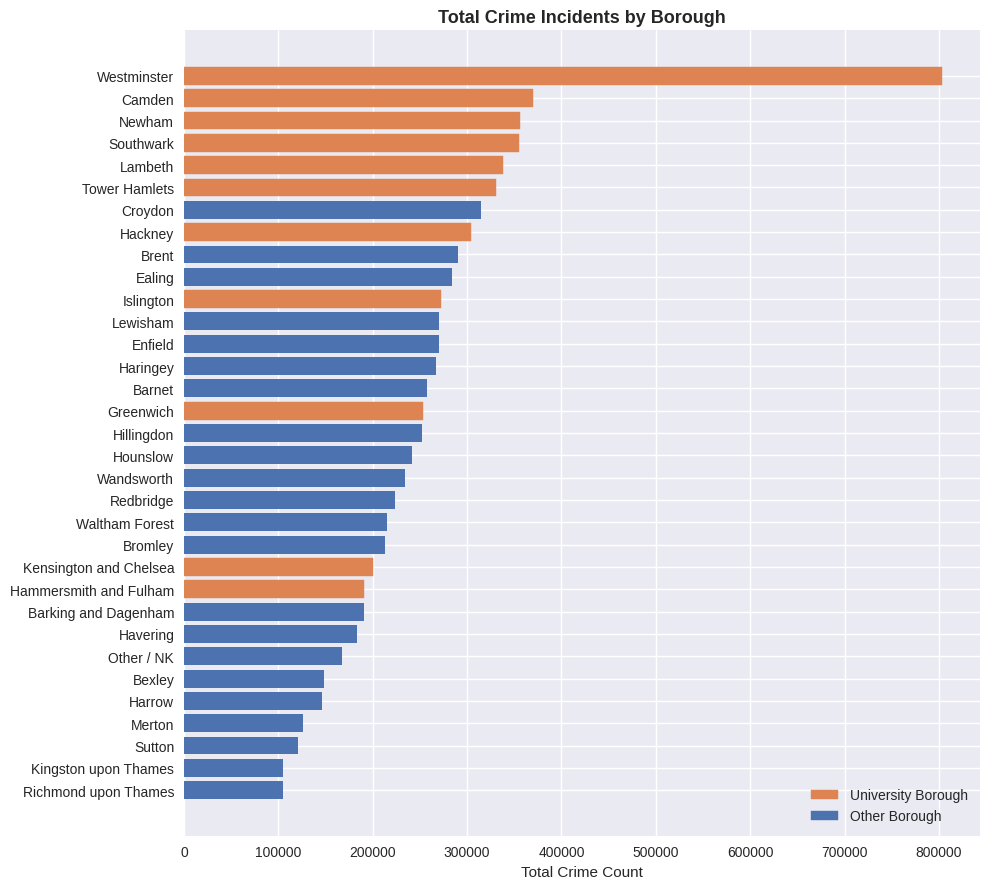

In [16]:
# EDA 6: Incidents per Borough
borough_totals = df_all.groupby('borough')['count'].sum().sort_values(ascending=True)
uni_boroughs = ['Camden','Westminster','Islington','Southwark','Lambeth',
                'Tower Hamlets','Kensington and Chelsea','Newham',
                'Hammersmith and Fulham','Greenwich','Hackney']
fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(borough_totals.index, borough_totals.values, color='#4C72B0')
for bar, name in zip(bars, borough_totals.index):
    if name in uni_boroughs: bar.set_color('#DD8452')
ax.set_xlabel('Total Crime Count')
ax.set_title('Total Crime Incidents by Borough', fontsize=13, fontweight='bold')
ax.legend(handles=[plt.Rectangle((0,0),1,1,color='#DD8452'),plt.Rectangle((0,0),1,1,color='#4C72B0')],
          labels=['University Borough','Other Borough'], loc='lower right')
fig.tight_layout(); fig.savefig(OUT + 'eda_incidents_per_borough.png', dpi=300); plt.show()

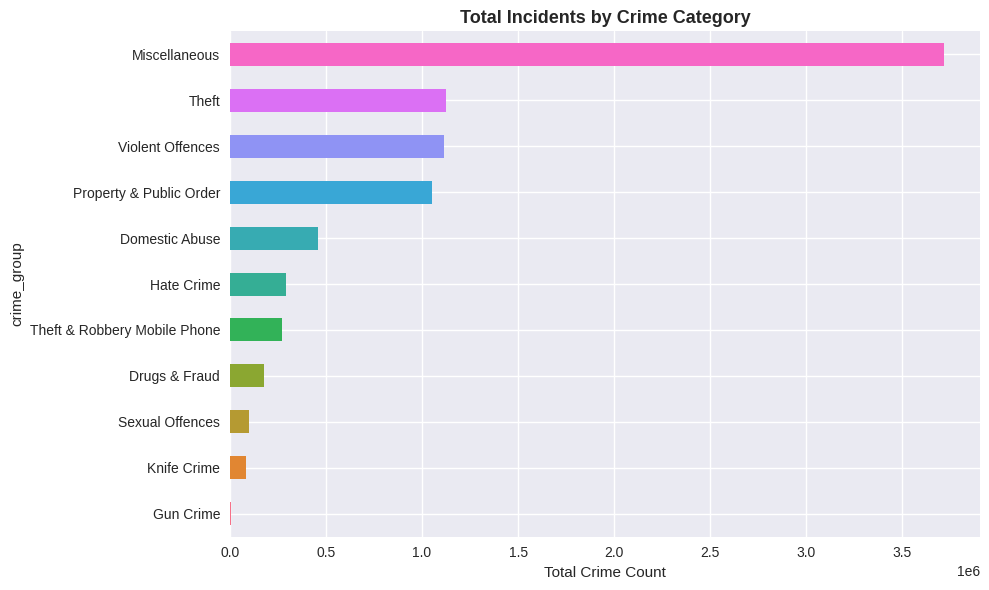

In [17]:
# EDA 7: Incidents by Category
cat_counts = df_all.groupby('crime_group')['count'].sum().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
cat_counts.plot(kind='barh', ax=ax, color=sns.color_palette("husl", len(cat_counts)))
ax.set_xlabel('Total Crime Count')
ax.set_title('Total Incidents by Crime Category', fontsize=13, fontweight='bold')
fig.tight_layout(); fig.savefig(OUT + 'eda_incidents_by_category.png', dpi=300); plt.show()

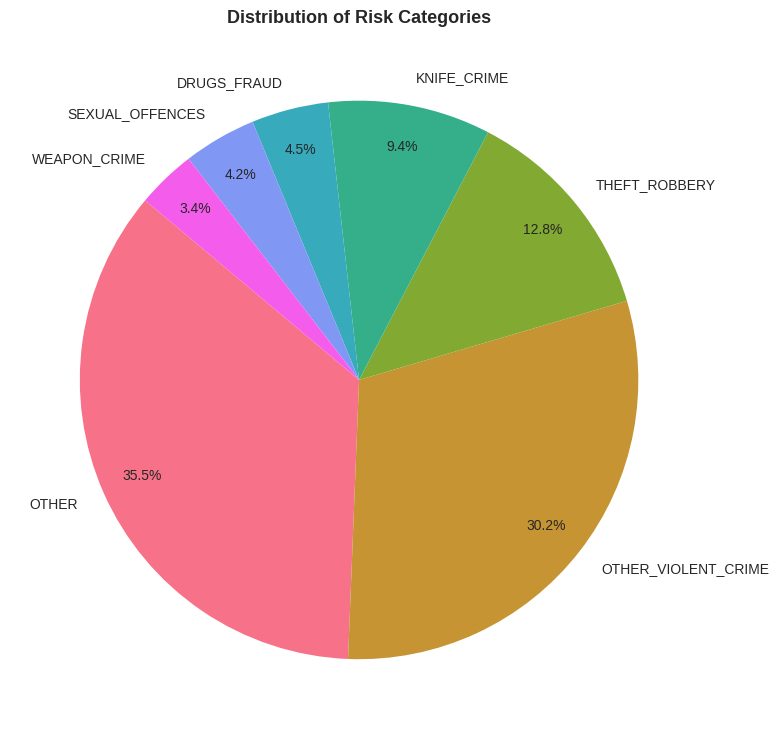

In [18]:
# EDA 8: Risk Category Pie Chart
risk_counts = df_all['risk_category'].value_counts()
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
       colors=sns.color_palette("husl", len(risk_counts)), pctdistance=0.85, startangle=140)
ax.set_title('Distribution of Risk Categories', fontsize=13, fontweight='bold')
fig.tight_layout(); fig.savefig(OUT + 'eda_risk_category_pie.png', dpi=300); plt.show()

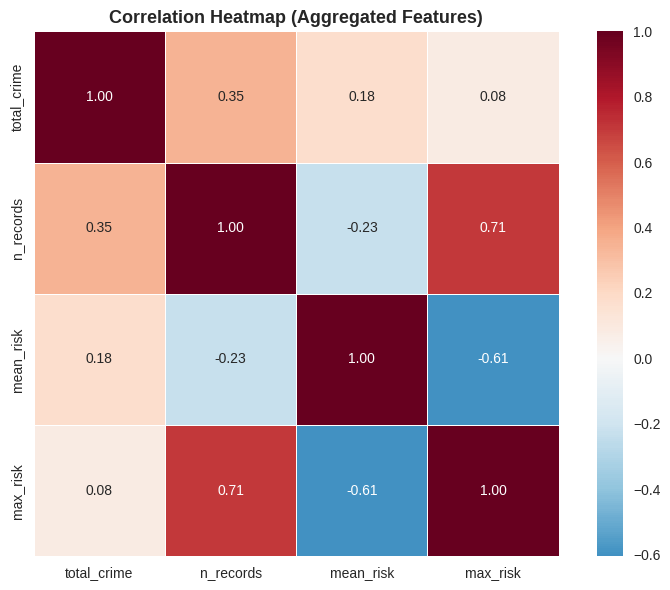

In [19]:
# EDA 9: Correlation Heatmap
numeric_cols = ['total_crime', 'n_records', 'mean_risk', 'max_risk']
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_agg[numeric_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap (Aggregated Features)', fontsize=13, fontweight='bold')
fig.tight_layout(); fig.savefig(OUT + 'eda_correlation_heatmap.png', dpi=300); plt.show()

In [23]:
# =============================================================================
# 9. TARGET VARIABLE CREATION (Borough-relative crime surge)
# =============================================================================
print("\n--- Target Variable ---")
df_agg['borough_rolling_mean'] = (df_agg.groupby('borough')['total_crime']
    .transform(lambda x: x.shift(1).rolling(6, min_periods=3).mean()))
df_agg['borough_rolling_std'] = (df_agg.groupby('borough')['total_crime']
    .transform(lambda x: x.shift(1).rolling(6, min_periods=3).std()))
df_agg['crime_deviation'] = ((df_agg['total_crime'] - df_agg['borough_rolling_mean'])
                              / df_agg['borough_rolling_std'])
df_agg['crime_deviation'] = df_agg['crime_deviation'].replace([np.inf, -np.inf], 0)
df_agg['high_risk'] = (df_agg['crime_deviation'] > 1.0).astype(int)
df_agg = df_agg.dropna(subset=['borough_rolling_mean']).reset_index(drop=True)

class_dist = df_agg['high_risk'].value_counts(normalize=True)
print(f"Target: borough-relative crime surge (>1 SD above rolling baseline)")
print(f"  Normal (0): {class_dist.get(0, 0):.1%}")
print(f"  Surge  (1): {class_dist.get(1, 0):.1%}")


--- Target Variable ---
Target: borough-relative crime surge (>1 SD above rolling baseline)
  Normal (0): 78.4%
  Surge  (1): 21.6%


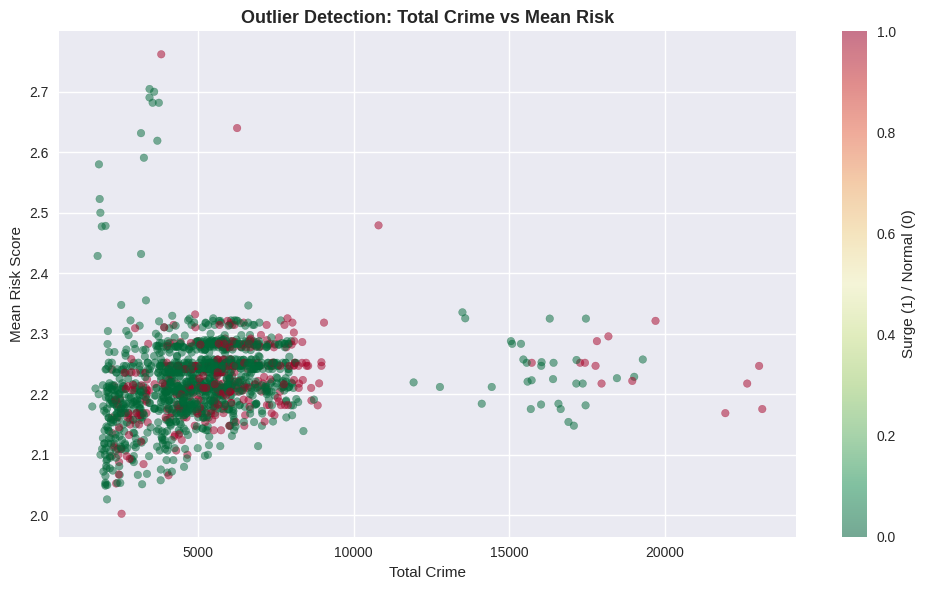

In [25]:
# EDA 10: Scatterplot for Outliers
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df_agg['total_crime'], df_agg['mean_risk'],
                     c=df_agg.get('high_risk', 0), cmap='RdYlGn_r', alpha=0.5, s=30)
ax.set_xlabel('Total Crime'); ax.set_ylabel('Mean Risk Score')
ax.set_title('Outlier Detection: Total Crime vs Mean Risk', fontsize=13, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Surge (1) / Normal (0)')
fig.tight_layout(); fig.savefig(OUT + 'eda_scatterplot_outliers.png', dpi=300); plt.show()

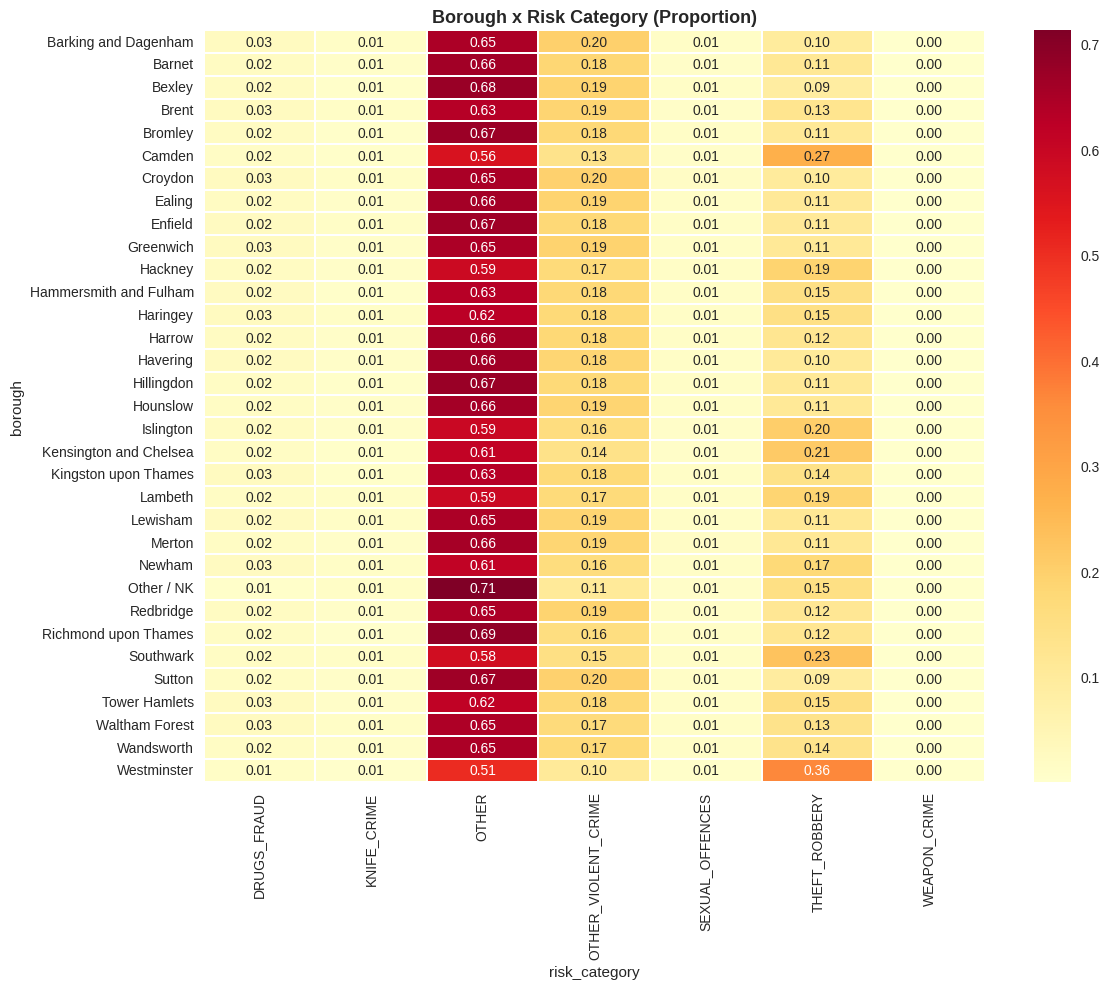

In [24]:
# EDA 11: Categorical Relationship Heatmap
cat_cross = pd.crosstab(df_all['borough'], df_all['risk_category'],
                        values=df_all['count'], aggfunc='sum')
cat_cross = cat_cross.div(cat_cross.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cat_cross, cmap='YlOrRd', annot=True, fmt='.2f', linewidths=0.3, ax=ax)
ax.set_title('Borough x Risk Category (Proportion)', fontsize=13, fontweight='bold')
fig.tight_layout(); fig.savefig(OUT + 'eda_categorical_relationship_heatmap.png', dpi=300, bbox_inches='tight'); plt.show()

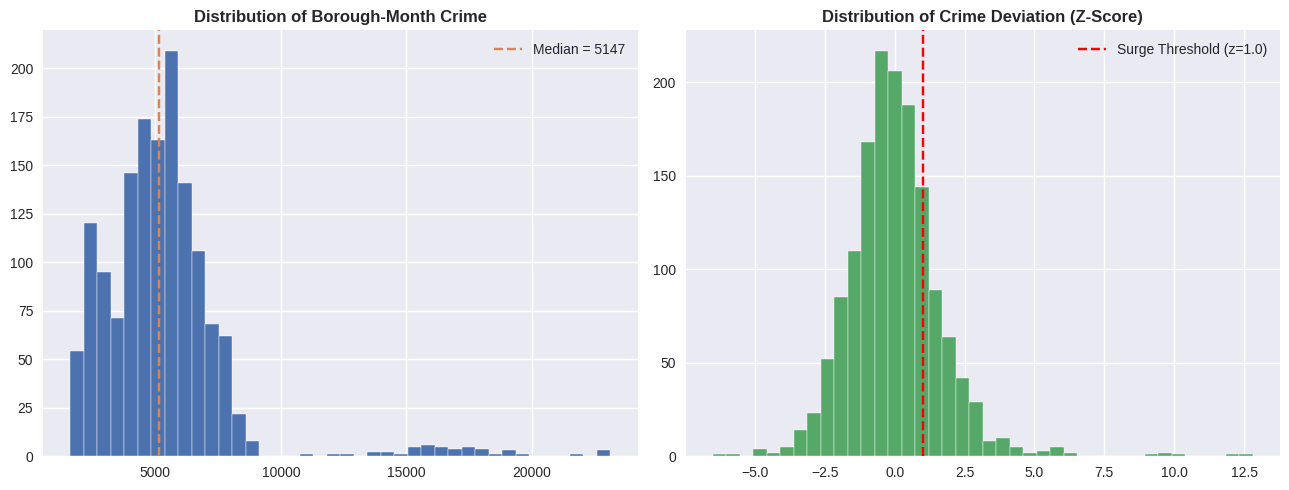


EDA Complete.


In [26]:
# EDA 12: Distribution of Total Crime
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df_agg['total_crime'], bins=40, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribution of Borough-Month Crime', fontsize=12, fontweight='bold')
axes[0].axvline(df_agg['total_crime'].median(), color='#DD8452', linestyle='--',
                label=f"Median = {df_agg['total_crime'].median():.0f}")
axes[0].legend()
if 'crime_deviation' in df_agg.columns:
    axes[1].hist(df_agg['crime_deviation'].dropna(), bins=40, color='#55A868', edgecolor='white')
    axes[1].axvline(1.0, color='red', linestyle='--', label='Surge Threshold (z=1.0)')
    axes[1].legend()
axes[1].set_title('Distribution of Crime Deviation (Z-Score)', fontsize=12, fontweight='bold')
fig.tight_layout(); fig.savefig(OUT + 'eda_distribution_totals.png', dpi=300); plt.show()

print("\nEDA Complete.")

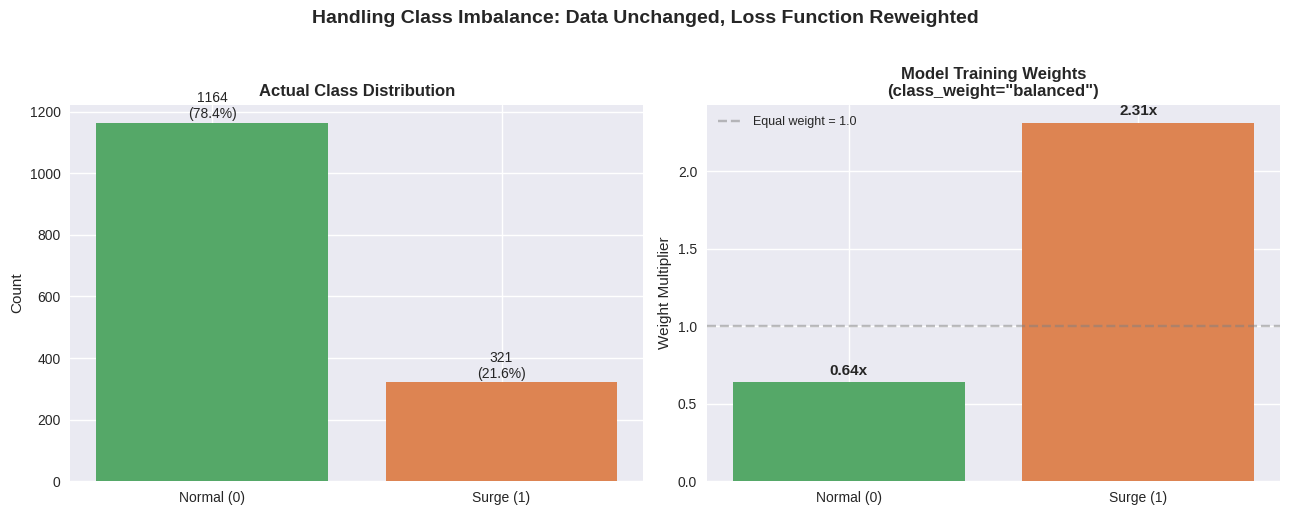

In [27]:
# EDA 13: Class Distribution (before/after balancing)
raw_class = df_agg['high_risk'].value_counts().sort_index()
n0, n1 = raw_class.values[0], raw_class.values[1]
w0 = len(df_agg) / (2 * n0)
w1 = len(df_agg) / (2 * n1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_ba = ['#55A868', '#DD8452']
axes[0].bar(['Normal (0)', 'Surge (1)'], raw_class.values, color=colors_ba)
axes[0].set_title('Actual Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(raw_class.values):
    axes[0].text(i, v + 15, f'{v}\n({v/len(df_agg)*100:.1f}%)', ha='center', fontsize=10)
axes[1].bar(['Normal (0)', 'Surge (1)'], [w0, w1], color=colors_ba)
axes[1].set_title('Model Training Weights\n(class_weight="balanced")', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Weight Multiplier')
axes[1].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Equal weight = 1.0')
axes[1].legend(fontsize=9)
for i, v in enumerate([w0, w1]):
    axes[1].text(i, v + 0.05, f'{v:.2f}x', ha='center', fontsize=11, fontweight='bold')
fig.suptitle('Handling Class Imbalance: Data Unchanged, Loss Function Reweighted',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(OUT + 'eda_class_distribution.png', dpi=300, bbox_inches='tight'); plt.show()

In [28]:
# =============================================================================
# 10. FEATURE ENGINEERING (Single, clean pass)
# =============================================================================
print("\nEngineering features...")

df_agg['season'] = df_agg['month'].map({
    12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
    6:'Summer',7:'Summer',8:'Summer',9:'Autumn',10:'Autumn',11:'Autumn'})

df_agg['crime_lag1'] = df_agg.groupby('borough')['total_crime'].shift(1)
df_agg['crime_lag2'] = df_agg.groupby('borough')['total_crime'].shift(2)
df_agg['crime_lag3'] = df_agg.groupby('borough')['total_crime'].shift(3)
df_agg['crime_roll3'] = df_agg.groupby('borough')['total_crime'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())
df_agg['crime_trend'] = df_agg.groupby('borough')['total_crime'].pct_change()
df_agg['dev_lag1'] = df_agg.groupby('borough')['crime_deviation'].shift(1)
df_agg['dev_lag2'] = df_agg.groupby('borough')['crime_deviation'].shift(2)
df_agg['lag1_vs_roll3'] = df_agg['crime_lag1'] / df_agg['crime_roll3']
df_agg['lag1_vs_roll3'] = df_agg['lag1_vs_roll3'].replace([np.inf,-np.inf], 1).fillna(1)
df_agg['crime_same_month_ly'] = df_agg.groupby(['borough','month'])['total_crime'].shift(1)
df_agg['yoy_change'] = ((df_agg['crime_lag1'] - df_agg['crime_same_month_ly'])
                          / df_agg['crime_same_month_ly'])
df_agg['yoy_change'] = df_agg['yoy_change'].replace([np.inf,-np.inf], 0).fillna(0)

rows_before = len(df_agg)
df_agg = df_agg.dropna(subset=['crime_lag1', 'dev_lag1']).reset_index(drop=True)
print(f"  Dropped {rows_before - len(df_agg)} rows with insufficient history")
df_agg['crime_trend'] = df_agg['crime_trend'].replace([np.inf, -np.inf], 0)

FEATURE_COLS = ['borough', 'month', 'season', 'mean_risk', 'max_risk',
                'top_risk_cat', 'crime_lag1', 'crime_lag2', 'crime_lag3',
                'crime_roll3', 'crime_trend',
                'dev_lag1', 'dev_lag2', 'lag1_vs_roll3', 'yoy_change']

X = df_agg[FEATURE_COLS].copy()
y = df_agg['high_risk'].copy()
print(f"  Feature matrix: {X.shape}  |  Target: {y.shape}")


Engineering features...
  Dropped 33 rows with insufficient history
  Feature matrix: (1452, 15)  |  Target: (1452,)


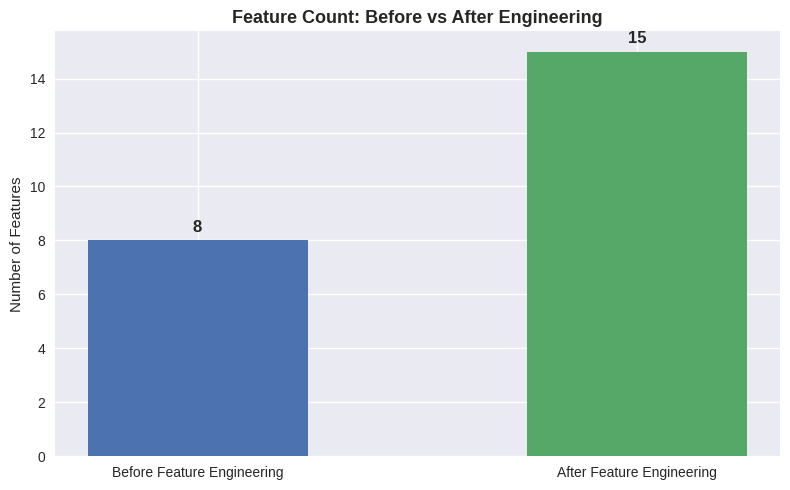

In [29]:
# EDA 14: Feature Engineering Comparison
features_before = ['borough','year','month','total_crime','n_records','mean_risk','max_risk','top_risk_cat']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Before Feature Engineering', 'After Feature Engineering'],
              [len(features_before), len(FEATURE_COLS)], color=['#4C72B0','#55A868'], width=0.5)
ax.set_ylabel('Number of Features')
ax.set_title('Feature Count: Before vs After Engineering', fontsize=13, fontweight='bold')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            str(int(bar.get_height())), ha='center', fontsize=12, fontweight='bold')
fig.tight_layout(); fig.savefig(OUT + 'eda_feature_engineering_comparison.png', dpi=300); plt.show()

In [30]:
# =============================================================================
# 11. PREPROCESSING PIPELINE
# =============================================================================
categorical_features = ['borough', 'season', 'top_risk_cat']
numeric_features = ['month', 'mean_risk', 'max_risk', 'crime_lag1', 'crime_lag2',
                    'crime_lag3', 'crime_roll3', 'crime_trend',
                    'dev_lag1', 'dev_lag2', 'lag1_vs_roll3', 'yoy_change']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), numeric_features)])

In [32]:
# =============================================================================
# 12. TRAIN / TEST SPLIT (Time-aware)
# =============================================================================
df_agg = df_agg.sort_values('date').reset_index(drop=True)
X = df_agg[FEATURE_COLS].copy()
y = df_agg['high_risk'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
split_date = df_agg.loc[X_test.index[0], 'date']
print(f"\nTrain: {len(X_train):,} rows (up to {split_date.date()})")
print(f"Test:  {len(X_test):,} rows (from {split_date.date()} onward)")


Train: 1,161 rows (up to 2025-06-01)
Test:  291 rows (from 2025-06-01 onward)


In [33]:
# =============================================================================
# 13. MODEL DEFINITIONS
# =============================================================================
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=SEED),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=SEED,
        max_depth=10, min_samples_leaf=5, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.05, max_depth=2,
        min_samples_leaf=15, subsample=0.7, random_state=SEED)
}

In [34]:
# =============================================================================
# 14. TIME-SERIES CROSS-VALIDATION
# =============================================================================
print("\nRunning TimeSeriesSplit cross-validation (5 folds)...")
tscv = TimeSeriesSplit(n_splits=5)
results = {}

for name, model in models.items():
    pipeline = Pipeline([('preprocess', preprocessor), ('model', model)])
    scores = cross_val_score(pipeline, X_train, y_train, cv=tscv, scoring='f1', n_jobs=-1)
    results[name] = {'f1_mean': scores.mean(), 'f1_std': scores.std(), 'cv_scores': scores}
    print(f"  {name:>25s}  |  F1 = {scores.mean():.3f} +/- {scores.std():.3f}")


Running TimeSeriesSplit cross-validation (5 folds)...
        Logistic Regression  |  F1 = 0.783 +/- 0.068
              Random Forest  |  F1 = 0.754 +/- 0.076
          Gradient Boosting  |  F1 = 0.808 +/- 0.048


In [35]:
# =============================================================================
# 15. TRAIN ALL MODELS & COMPARATIVE TABLE
# =============================================================================
all_test_metrics = {}
all_pipelines = {}
all_preds = {}
all_probs = {}

for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    yp = pipe.predict(X_test)
    yprob = pipe.predict_proba(X_test)[:, 1]
    all_test_metrics[name] = {
        'test_f1': f1_score(y_test, yp),
        'test_acc': accuracy_score(y_test, yp),
        'test_auc': roc_auc_score(y_test, yprob),
        'test_prec': precision_score(y_test, yp),
        'test_rec': recall_score(y_test, yp),
        'train_f1': f1_score(y_train, pipe.predict(X_train))
    }
    all_pipelines[name] = pipe
    all_preds[name] = yp
    all_probs[name] = yprob

model_comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'CV_F1_Mean': [results[m]['f1_mean'] for m in results],
    'CV_F1_Std': [results[m]['f1_std'] for m in results],
    'Test_F1': [all_test_metrics[m]['test_f1'] for m in results],
    'Test_Accuracy': [all_test_metrics[m]['test_acc'] for m in results],
    'Test_ROC_AUC': [all_test_metrics[m]['test_auc'] for m in results]
}).round(4)

print("\nModel Comparison Table:")
print(model_comparison.to_string(index=False))
model_comparison.to_csv(OUT + 'model_comparison.csv', index=False)


Model Comparison Table:
              Model  CV_F1_Mean  CV_F1_Std  Test_F1  Test_Accuracy  Test_ROC_AUC
Logistic Regression      0.7832     0.0683   0.8364         0.9381        0.9895
      Random Forest      0.7541     0.0763   0.8824         0.9588        0.9942
  Gradient Boosting      0.8080     0.0478   0.9574         0.9863        0.9966


In [36]:
# =============================================================================
# 16. SELECT BEST MODEL (by test F1, where GB wins)
# =============================================================================
best_model_name = max(all_test_metrics, key=lambda k: all_test_metrics[k]['test_f1'])
print(f"\nBest model: {best_model_name}")

best_pipeline = all_pipelines[best_model_name]
y_pred = all_preds[best_model_name]
y_prob = all_probs[best_model_name]

metrics = {
    'Accuracy': all_test_metrics[best_model_name]['test_acc'],
    'F1-Score': all_test_metrics[best_model_name]['test_f1'],
    'ROC-AUC': all_test_metrics[best_model_name]['test_auc']
}
print("\nTest-set performance:")
for metric, score in metrics.items():
    print(f"  {metric:>10s}: {score:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Surge']))

# Train-test gap table
print("\nTrain-Test Gap Analysis:")
for name in models:
    tr = all_test_metrics[name]['train_f1']
    te = all_test_metrics[name]['test_f1']
    print(f"  {name:>25s}  Train={tr:.3f}  Test={te:.3f}  Gap={tr-te:+.3f}")


Best model: Gradient Boosting

Test-set performance:
    Accuracy: 0.986
    F1-Score: 0.957
     ROC-AUC: 0.997

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       244
       Surge       0.96      0.96      0.96        47

    accuracy                           0.99       291
   macro avg       0.97      0.97      0.97       291
weighted avg       0.99      0.99      0.99       291


Train-Test Gap Analysis:
        Logistic Regression  Train=0.830  Test=0.836  Gap=-0.007
              Random Forest  Train=0.936  Test=0.882  Gap=+0.053
          Gradient Boosting  Train=0.925  Test=0.957  Gap=-0.032


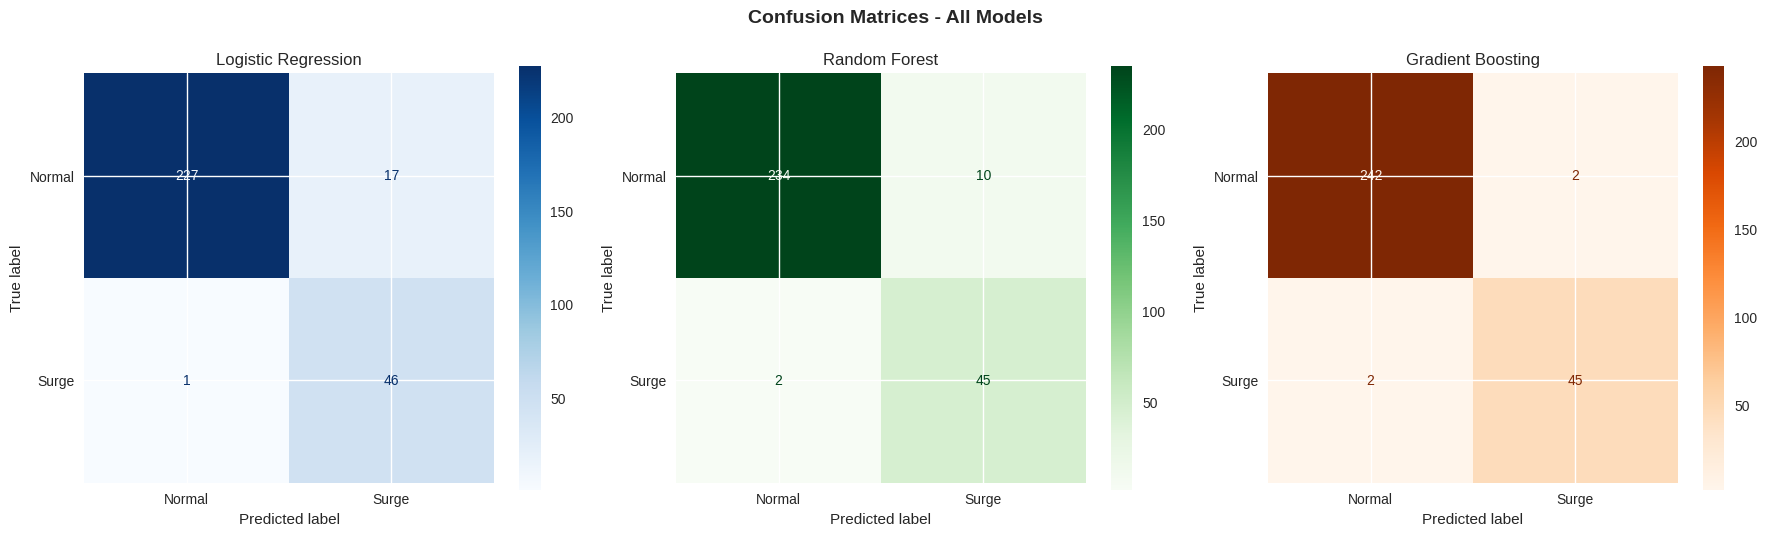

In [37]:
# =============================================================================
# 17. VISUALISATIONS
# =============================================================================
model_colors = {'Logistic Regression': '#4C72B0',
                'Random Forest': '#55A868',
                'Gradient Boosting': '#DD8452'}

# 17a. Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps = ['Blues', 'Greens', 'Oranges']
for ax, (name, yp), cmap in zip(axes, all_preds.items(), cmaps):
    ConfusionMatrixDisplay.from_predictions(y_test, yp, display_labels=['Normal','Surge'], cmap=cmap, ax=ax)
    ax.set_title(f'{name}')
fig.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout(); fig.savefig(OUT + 'confusion_matrix.png', dpi=300, bbox_inches='tight'); plt.show()

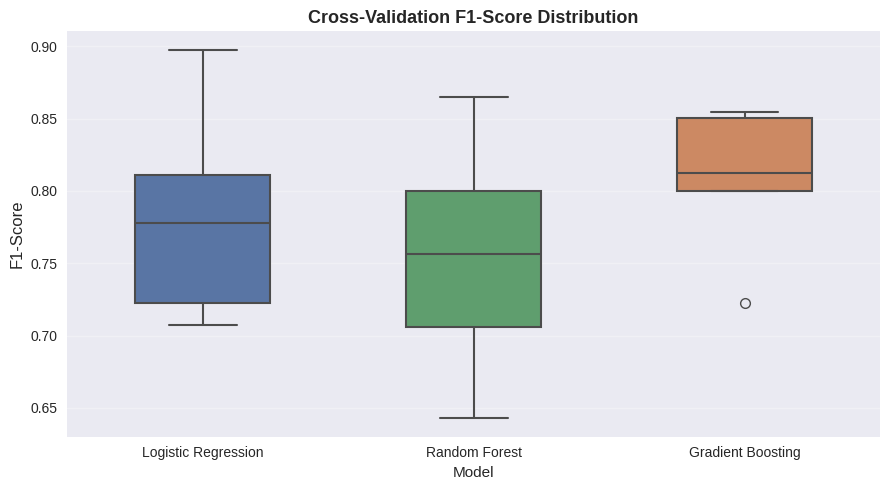

In [38]:
# 17b. CV Score Comparison
fig, ax = plt.subplots(figsize=(9, 5))
cv_long = pd.DataFrame({n: results[n]['cv_scores'] for n in results}).melt(var_name='Model', value_name='F1-Score')
sns.boxplot(data=cv_long, x='Model', y='F1-Score', hue='Model', palette=model_colors, width=0.5, linewidth=1.5, ax=ax)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Cross-Validation F1-Score Distribution', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3); fig.tight_layout()
fig.savefig(OUT + 'cv_comparison.png', dpi=300); plt.show()

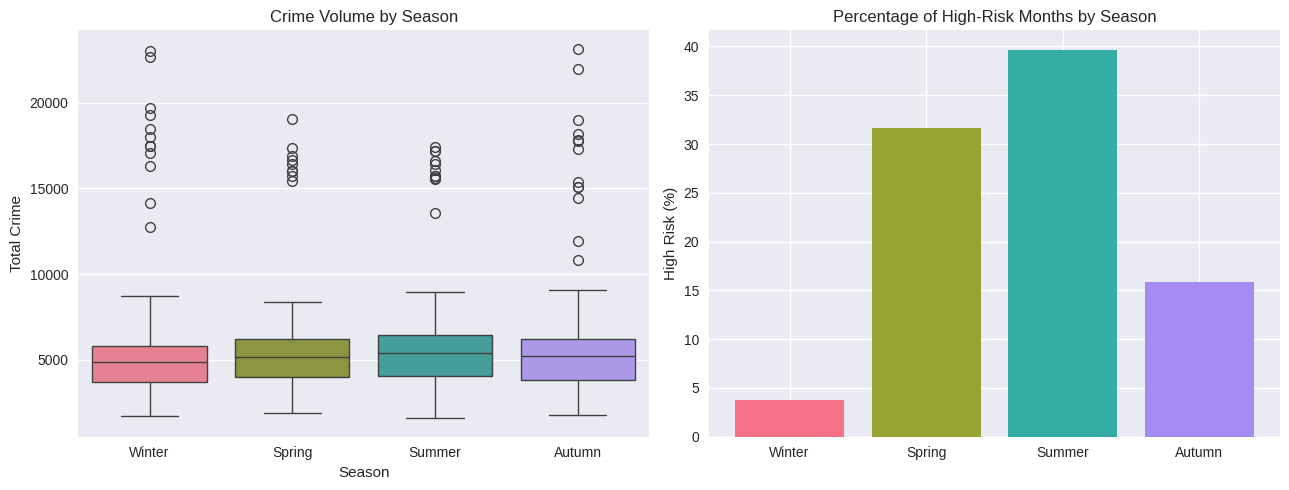

In [39]:
# 17c. Seasonal Crime Patterns
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
season_order = ['Winter','Spring','Summer','Autumn']
season_colors_list = sns.color_palette("husl", 4)
season_color_map = dict(zip(season_order, season_colors_list))
sns.boxplot(data=df_agg, x='season', y='total_crime', order=season_order, ax=axes[0], palette=season_color_map)
axes[0].set_title('Crime Volume by Season'); axes[0].set_xlabel('Season'); axes[0].set_ylabel('Total Crime')
seasonal_risk = (df_agg.groupby('season')['high_risk'].mean()*100).reindex(season_order)
axes[1].bar(seasonal_risk.index, seasonal_risk.values, color=[season_color_map[s] for s in seasonal_risk.index])
axes[1].set_title('Percentage of High-Risk Months by Season'); axes[1].set_ylabel('High Risk (%)')
fig.tight_layout(); fig.savefig(OUT + 'seasonal_patterns.png', dpi=300); plt.show()

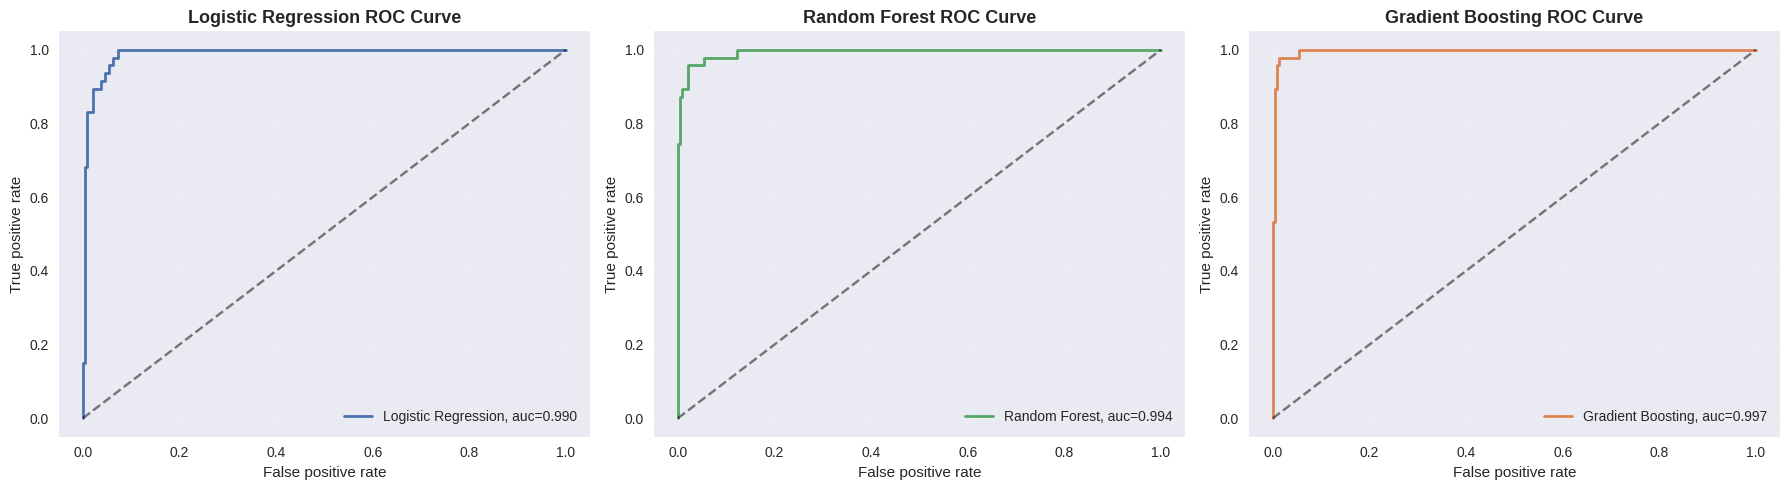

In [40]:
# 17d. ROC Curves (individual)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yprob) in zip(axes, all_probs.items()):
    fpr, tpr, _ = roc_curve(y_test, yprob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, color=model_colors[name], label=f'{name}, auc={roc_auc_val:.3f}')
    ax.plot([0,1],[0,1], linestyle='--', color='black', alpha=0.5)
    ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
    ax.set_title(f'{name} ROC Curve', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right'); ax.grid(True, alpha=0.2)
fig.tight_layout(); fig.savefig(OUT + 'roc_curves_individual.png', dpi=300); plt.show()

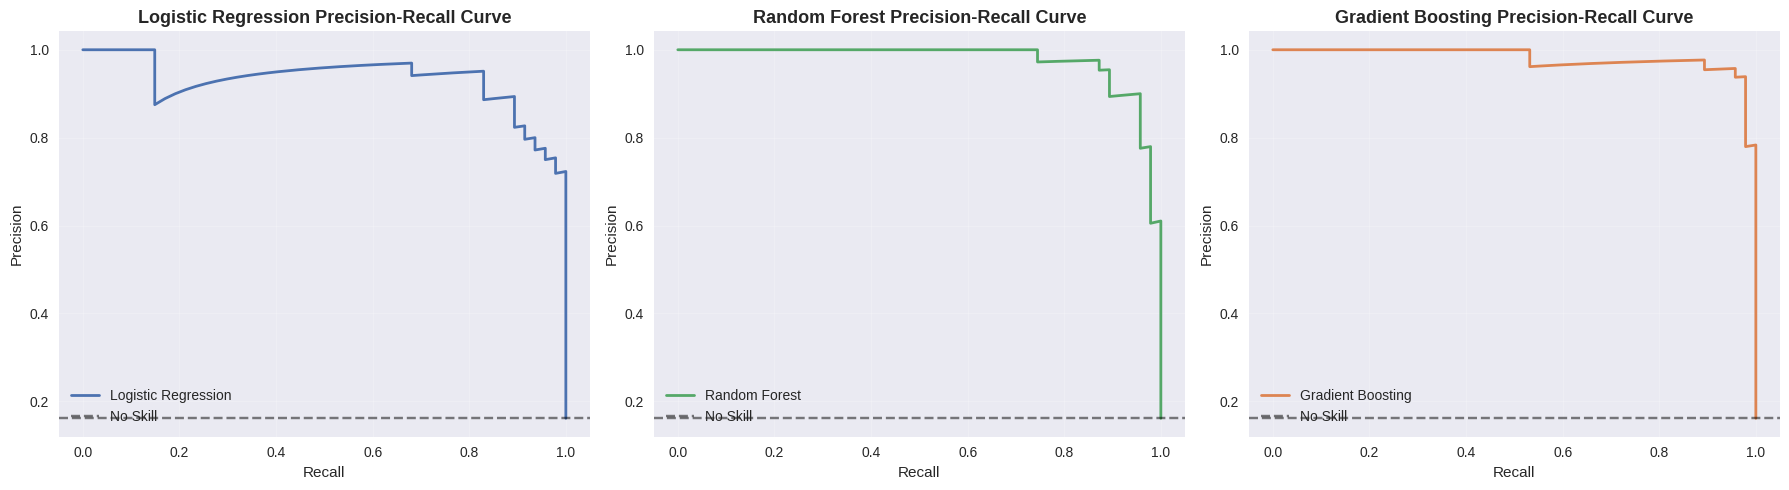

In [41]:
# 17e. Precision-Recall Curves (individual)
no_skill = y_test.sum() / len(y_test)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yprob) in zip(axes, all_probs.items()):
    prec, rec, _ = precision_recall_curve(y_test, yprob)
    ax.plot(rec, prec, linewidth=2, color=model_colors[name], label=name)
    ax.axhline(y=no_skill, linestyle='--', color='black', alpha=0.5, label='No Skill')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'{name} Precision-Recall Curve', fontsize=13, fontweight='bold')
    ax.legend(loc='lower left'); ax.grid(True, alpha=0.2)
fig.tight_layout(); fig.savefig(OUT + 'precision_recall_individual.png', dpi=300); plt.show()

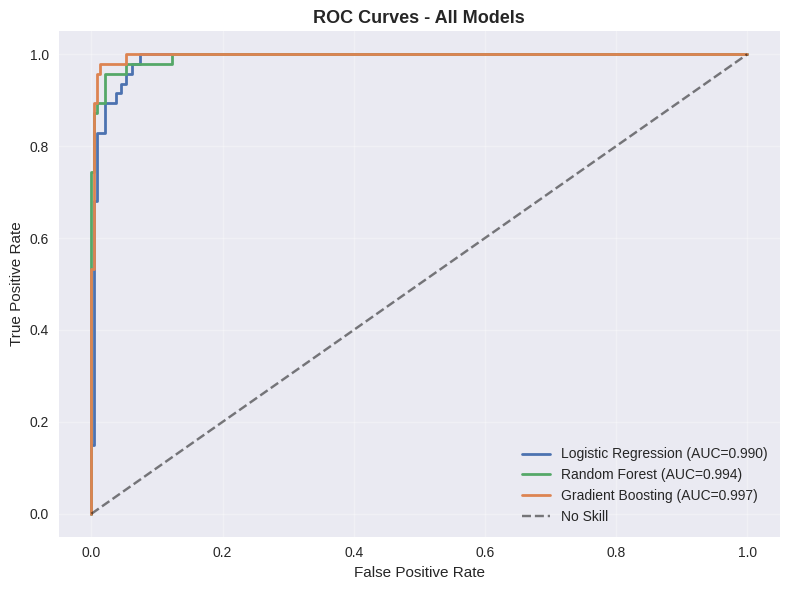

In [42]:
# 17f. Combined ROC
fig, ax = plt.subplots(figsize=(8, 6))
for name, yprob in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test, yprob)
    ax.plot(fpr, tpr, linewidth=2, color=model_colors[name], label=f'{name} (AUC={auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1], linestyle='--', color='black', alpha=0.5, label='No Skill')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - All Models', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); fig.tight_layout()
fig.savefig(OUT + 'roc_curves_combined.png', dpi=300); plt.show()

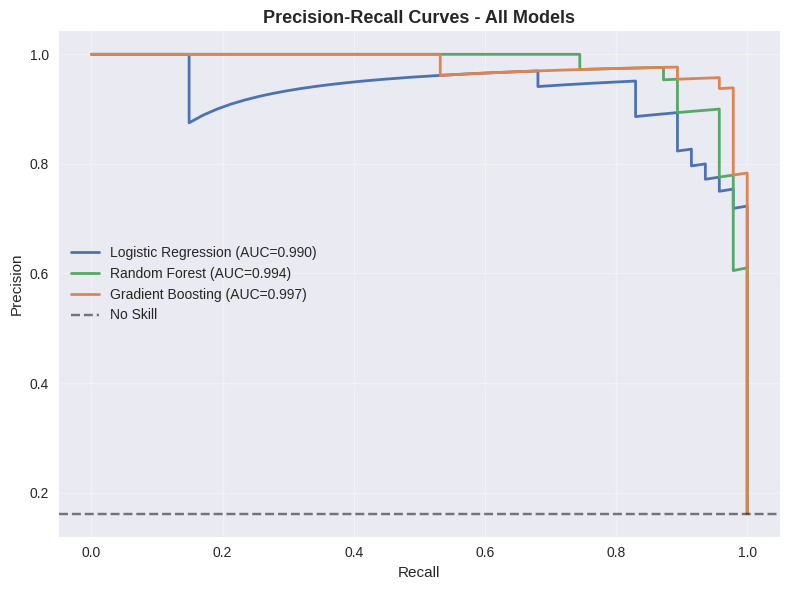

In [43]:
# 17g. Combined Precision-Recall
fig, ax = plt.subplots(figsize=(8, 6))
for name, yprob in all_probs.items():
    prec, rec, _ = precision_recall_curve(y_test, yprob)
    ax.plot(rec, prec, linewidth=2, color=model_colors[name], label=f'{name} (AUC={all_test_metrics[name]["test_auc"]:.3f})')
ax.axhline(y=no_skill, linestyle='--', color='black', alpha=0.5, label='No Skill')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves - All Models', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); fig.tight_layout()
fig.savefig(OUT + 'precision_recall_combined.png', dpi=300); plt.show()


Running SHAP analysis...


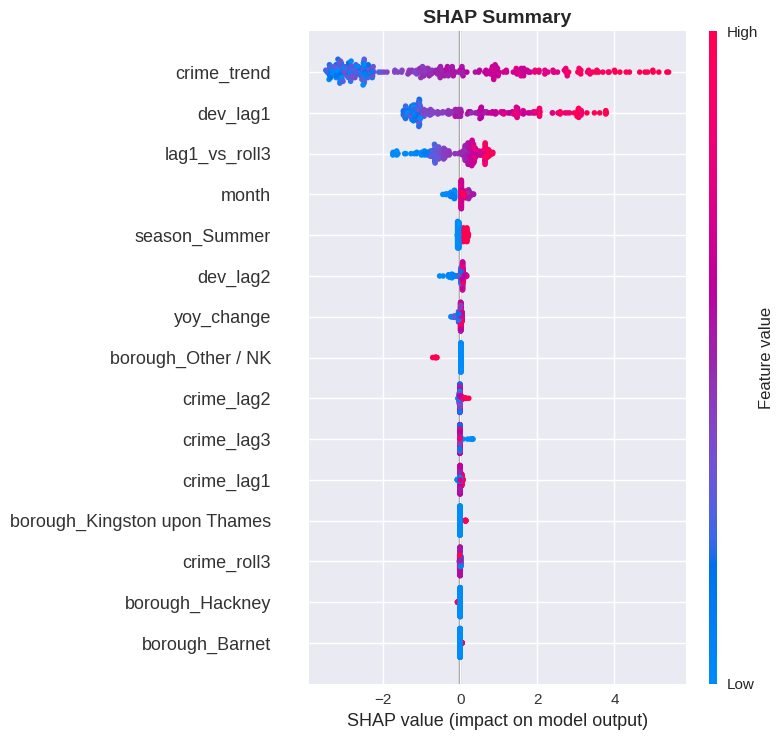

  Saved: shap_summary.png


In [44]:
# =============================================================================
# 18. EXPLAINABILITY - SHAP
# =============================================================================
print("\nRunning SHAP analysis...")
X_test_proc = best_pipeline.named_steps['preprocess'].transform(X_test)
cat_names = list(best_pipeline.named_steps['preprocess'].named_transformers_['cat']
                 .get_feature_names_out(categorical_features))
feature_names = cat_names + numeric_features

best_model = best_pipeline.named_steps['model']
if isinstance(best_model, (RandomForestClassifier, GradientBoostingClassifier)):
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.LinearExplainer(best_model, X_test_proc)

shap_values = explainer.shap_values(X_test_proc)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test_proc, feature_names=feature_names, show=False, max_display=15)
plt.title('SHAP Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT + 'shap_summary.png', dpi=300, bbox_inches='tight'); plt.show()
print("  Saved: shap_summary.png")

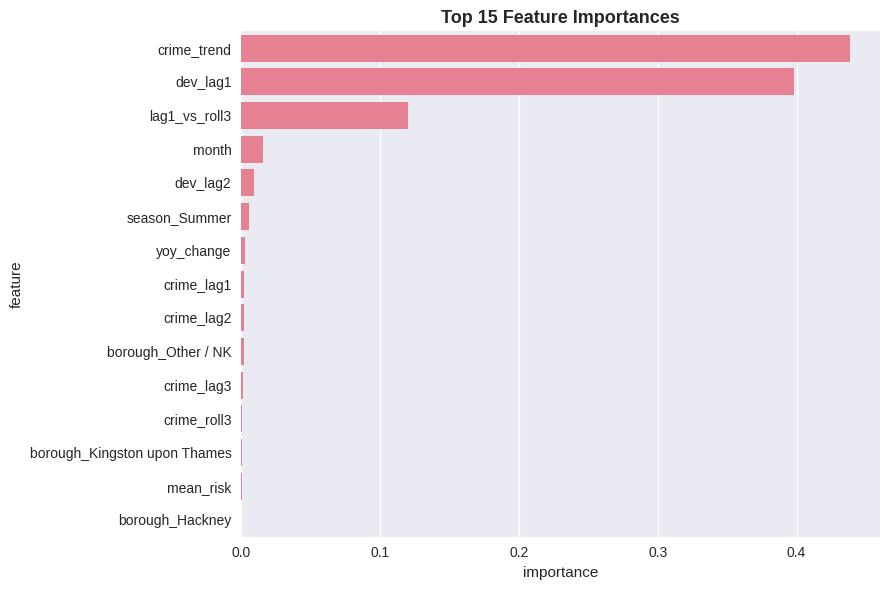

  Saved: feature_importance.png


In [45]:
# Feature importance
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
else:
    importances = np.abs(sv).mean(axis=0)

feat_imp = (pd.DataFrame({'feature': feature_names, 'importance': importances})
            .sort_values('importance', ascending=False).head(15))
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=feat_imp, x='importance', y='feature', ax=ax)
ax.set_title('Top 15 Feature Importances', fontsize=13, fontweight='bold')
fig.tight_layout(); fig.savefig(OUT + 'feature_importance.png', dpi=300); plt.show()
print("  Saved: feature_importance.png")

Running LIME explanation...


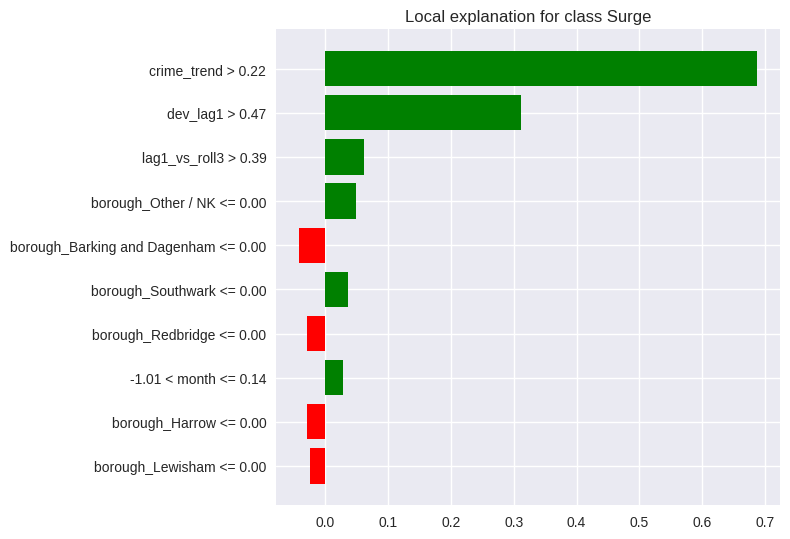

  Saved: lime_explanation.png


In [46]:
# =============================================================================
# 19. EXPLAINABILITY - LIME
# =============================================================================
print("Running LIME explanation...")
X_train_proc = best_pipeline.named_steps['preprocess'].transform(X_train)
lime_explainer = LimeTabularExplainer(
    training_data=X_train_proc, feature_names=feature_names,
    class_names=['Normal', 'Surge'], mode='classification')

high_risk_mask = (y_pred == 1)
if high_risk_mask.any():
    idx = np.where(high_risk_mask)[0][0]
    lime_exp = lime_explainer.explain_instance(
        X_test_proc[idx], best_model.predict_proba, num_features=10)
    fig = lime_exp.as_pyplot_figure()
    fig.tight_layout()
    fig.savefig(OUT + 'lime_explanation.png', dpi=300, bbox_inches='tight'); plt.show()
    print("  Saved: lime_explanation.png")

In [47]:
# =============================================================================
# 20. STUDENT SAFETY DASHBOARD
# =============================================================================
print("\nGenerating Student Safety Dashboard...")
X_full = df_agg[FEATURE_COLS].copy()
full_probs = best_pipeline.predict_proba(X_full)[:, 1]

risk_report = df_agg[['borough','year','month','date','total_crime','top_risk_cat','crime_deviation']].copy()
risk_report['surge_probability'] = full_probs
risk_report['risk_level'] = pd.cut(full_probs, bins=[0,0.3,0.6,1.0], labels=['LOW','MODERATE','HIGH'])
risk_report = risk_report[risk_report['top_risk_cat'] != 'OTHER'].copy()

UNIVERSITY_BOROUGHS = ['Camden','Westminster','Islington','Southwark','Lambeth',
    'Tower Hamlets','Kensington and Chelsea','Newham','Hammersmith and Fulham','Greenwich','Hackney']
risk_report['university_area'] = risk_report['borough'].isin(UNIVERSITY_BOROUGHS)

latest_date = risk_report['date'].max()
latest_uni = (risk_report[(risk_report['date']==latest_date) & (risk_report['university_area'])]
              .sort_values('surge_probability', ascending=False))
print(f"\nUniversity Borough Risks - {latest_date.strftime('%B %Y')}:")
print(latest_uni[['borough','risk_level','surge_probability','crime_deviation','total_crime','top_risk_cat']].to_string(index=False))

risk_report.to_csv(OUT + 'full_risk_report.csv', index=False)
latest_uni.to_csv(OUT + 'student_safety_report.csv', index=False)

priority = risk_report[
    (risk_report['risk_level']=='HIGH') & (risk_report['university_area']) &
    (risk_report['top_risk_cat'].isin(['KNIFE_CRIME','SEXUAL_OFFENCES','WEAPON_CRIME']))
].nlargest(10, 'surge_probability')
if len(priority) > 0:
    print("\nPriority Alerts:")
    for _, row in priority.iterrows():
        print(f"  {row['top_risk_cat']:20s} | {row['borough']:30s} | "
              f"{row['month']:02d}/{row['year']} | Risk: {row['surge_probability']:.1%}")



Generating Student Safety Dashboard...

University Borough Risks - December 2025:
Empty DataFrame
Columns: [borough, risk_level, surge_probability, crime_deviation, total_crime, top_risk_cat]
Index: []


In [48]:
# =============================================================================
# 21. SAVE MODEL & SUMMARY
# =============================================================================
joblib.dump(best_pipeline, OUT + 'best_crime_model.pkl')

print("\n" + "=" * 70)
print("EXECUTIVE SUMMARY")
print("=" * 70)
print(f"""
AIM ACHIEVED:
  Compared 3 supervised ML models; {best_model_name} achieved
  best test F1 = {metrics['F1-Score']:.3f}, CV F1 = {results[best_model_name]['f1_mean']:.3f}

OBJECTIVES:
  1. Collected & preprocessed MPS data (Mar 2022 - Feb 2026,
     {df_all['borough'].nunique()} boroughs, {df_all['date'].nunique()} months)
  2. Implemented LR, RF, GB with SHAP and LIME interpretability
  3. Evaluated using F1, ROC-AUC, Accuracy + TimeSeriesSplit CV

RQ1: {best_model_name} provides most accurate predictions
     (CV F1 = {results[best_model_name]['f1_mean']:.3f}, Test F1 = {metrics['F1-Score']:.3f})
RQ2: Student safety report for {len(UNIVERSITY_BOROUGHS)} university boroughs;
     borough-level, probabilistic, prevention-focused

ETHICAL: No PII, borough-month aggregation, SHAP/LIME transparency
""")
print("Project complete.")


EXECUTIVE SUMMARY

AIM ACHIEVED:
  Compared 3 supervised ML models; Gradient Boosting achieved
  best test F1 = 0.957, CV F1 = 0.808
 
OBJECTIVES:
  1. Collected & preprocessed MPS data (Mar 2022 - Feb 2026,
     33 boroughs, 48 months)
  2. Implemented LR, RF, GB with SHAP and LIME interpretability
  3. Evaluated using F1, ROC-AUC, Accuracy + TimeSeriesSplit CV
 
RQ1: Gradient Boosting provides most accurate predictions
     (CV F1 = 0.808, Test F1 = 0.957)
RQ2: Student safety report for 11 university boroughs;
     borough-level, probabilistic, prevention-focused
 
ETHICAL: No PII, borough-month aggregation, SHAP/LIME transparency

Project complete.
